In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)


# Load your dataset
data = pd.read_csv("C:\\Users\\ASUS\\Desktop\\New folder\\final dataset.csv")




In [89]:
# Preview data
print("✅ Dataset Loaded Successfully!")
print("Shape:", data.shape)
display(data.head())

✅ Dataset Loaded Successfully!
Shape: (1048575, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [91]:
# 3. Data Preprocessing (Simplified & Fixed)

# Drop ID-like columns (they don’t help prediction)
data = data.drop(['nameOrig', 'nameDest'], axis=1, errors='ignore')

# Encode the 'type' column (only this one is categorical)
data['type'] = data['type'].astype('category').cat.codes

print("Preprocessing Done. Columns are now numeric.")
print(data.dtypes)


Preprocessing Done. Columns are now numeric.
step                int64
type                 int8
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [99]:


X = data.drop('isFraud', axis=1)
y = data['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train-Test Split Done")

print("Training data:", len(X_train))
print("Testing data:", len(X_test))


Train-Test Split Done
Training data: 838860
Testing data: 209715


In [101]:


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Feature Scaling Completed Successfully")


 Feature Scaling Completed Successfully


In [103]:
y_pred = model.predict(X_test_scaled)
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.9991893760579834


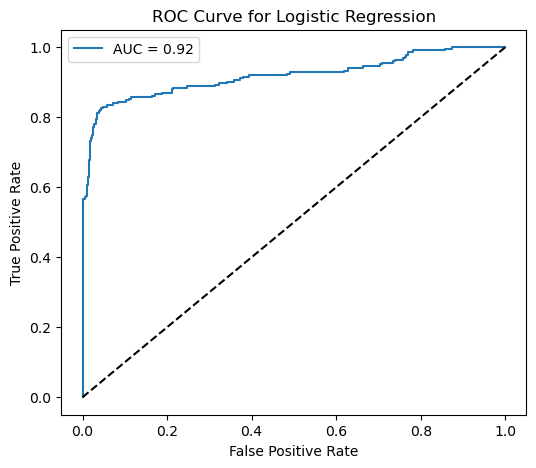

In [105]:
# 8. ROC Curve & AUC
y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.show()


In [108]:
 #9. Cross-Validation

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

print("\n Logistic Regression Analysis Completed Successfully!")



Cross-Validation Accuracy Scores: [0.99919534 0.99910593 0.99913573 0.9992609  0.99917149]
Mean CV Accuracy: 0.9991738788355626

 Logistic Regression Analysis Completed Successfully!


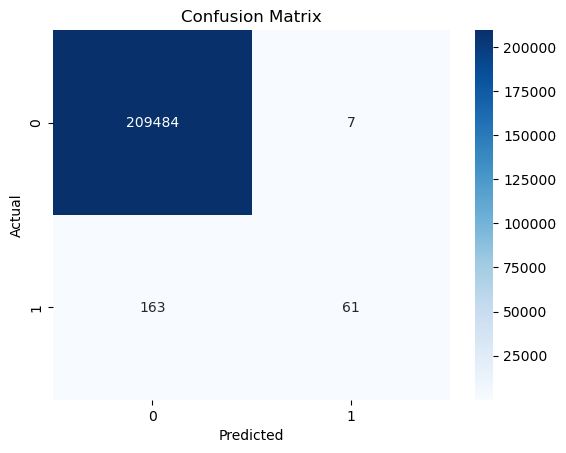

In [109]:
# Predict again (to get y_pred)
y_pred = model.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [54]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209491
           1       0.90      0.27      0.42       224

    accuracy                           1.00    209715
   macro avg       0.95      0.64      0.71    209715
weighted avg       1.00      1.00      1.00    209715

